# 02 — Wavelet decomposition

Each input series is split into a **trend** and a **seasonal** component by
multiresolution analysis with a discrete Meyer wavelet, applied at **its own native
cadence**, and the components are aggregated to monthly.

The trend/seasonal boundary is placed at one year: everything that repeats faster
than that is seasonality, everything slower is trend.

The notebook also quantifies the look-ahead carried by the trend component, which
is the second limitation declared in the work plan. That section reaches a
different conclusion from the Phase 1 reproduction, and the reason is set out where
it arises.

Input — `data/raw/`: `orchard_ndvi_16day.csv`, `orchard_lst_8day.csv`,
`orchard_monthly.csv`
Output — `data/processed/orchard_decomposed.csv`

In [1]:
import warnings

import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Expected at these levels and explained under "Boundary handling" below; silenced
# so the diagnostic output stays readable.
warnings.filterwarnings("ignore", message="Level value of .* is too high")

master = pd.read_csv("../data/raw/orchard_monthly.csv",
                     index_col="date", parse_dates=True)

ndvi16 = (pd.read_csv("../data/raw/orchard_ndvi_16day.csv", parse_dates=["date"])
            .set_index("date")["NDVI"])
lst8 = (pd.read_csv("../data/raw/orchard_lst_8day.csv", parse_dates=["date"])
          .set_index("date")["LST"])

SPEI_COLS = ["SPEI_1", "SPEI_3", "SPEI_6", "SPEI_12"]
ALL_SERIES = ["NDVI", "LST"] + SPEI_COLS

print(f"monthly {master.shape}   16-day NDVI {len(ndvi16)}   8-day LST {len(lst8)}")
print(f"NDVI composites masked as cloud: {ndvi16.isna().sum()} of {len(ndvi16)} -> interpolated")
print(f"LST composites withheld by MODIS: {lst8.isna().sum()} of {len(lst8)} -> interpolated")
ndvi16 = ndvi16.interpolate()
lst8 = lst8.interpolate()

monthly (298, 8)   16-day NDVI 571   8-day LST 1141
NDVI composites masked as cloud: 8 of 571 -> interpolated
LST composites withheld by MODIS: 8 of 1141 -> interpolated


## Choosing the levels

Multiresolution analysis splits a series into frequency bands by halving
repeatedly. Level 1 isolates the fastest wiggles — things repeating over about two
sampling intervals. Level 2 isolates things twice as slow, level 3 twice as slow
again. After `J` halvings one slow remainder is left, the **approximation** `A_J`,
holding everything slower than the last band removed. That remainder is the trend.

The level is therefore not a quality setting. It is a choice of **where to cut the
timescale axis** — how slow something must be before it counts as trend rather than
seasonality.

The timescale a given level cuts at depends on the sampling interval:

    scale  a = 2^J          semi-period  p = a · Δt / (2 · v_c)

where `v_c` is the wavelet's centre frequency. Targeting one year fixes the levels:
5 for 16-day NDVI, 6 for 8-day LST, 4 for monthly SPEI. In each case the
neighbouring levels are off by a factor of two, so the choice is unambiguous. The
levels differ across indices only because the cadences differ — 16-day NDVI needs
one fewer halving than 8-day LST to reach the same timescale.

These are the levels Bounouh et al. (2024) report in Table 3, and their reported
semi-periods confirm it: 385, 338 and 361 days are reproduced exactly with
`v_c = 0.6634` and Δt of 16, 7 and 30 days. Their 7-day interval for MOD11A2 — an
8-day composite — and their 30-day month are small approximations, neither large
enough to change which level is selected. The levels are derived here rather than
inherited, and the assertion below checks that the derivation agrees with the
published table.

**On `v_c`.** `pywt.central_frequency("dmey")` returns 0.6721; MATLAB's `centfrq`,
used in the source, returns 0.6634. The 1.3% difference shifts every semi-period by
about five days and changes no level. The pywt value is used here, since pywt
performs the decomposition.

**Why native cadence.** Applying level 5 to *monthly* NDVI would put the cut at 32
months rather than 13. That error was made and corrected during the Phase 1
reproduction, where it degraded every component.

**Why `dmey`.** The discrete Meyer wavelet gives the sharpest separation between
adjacent frequency bands of the common families. That matters here because the
entire method depends on the trend and the seasonal cycle not leaking into one
another — a point the look-ahead section returns to.

In [2]:
WAVELET = "dmey"
V_C = pywt.central_frequency(WAVELET)
CADENCE = {"NDVI": 16.0, "LST": 8.0, "SPEI": 365.25 / 12}
TARGET_DAYS = 365.25


def semi_period(level, dt):
    return 2 ** level * dt / (2 * V_C)


LEVELS = {k: min(range(2, 9), key=lambda j: abs(semi_period(j, dt) - TARGET_DAYS))
          for k, dt in CADENCE.items()}

print(f"{WAVELET}: centre frequency {V_C:.4f}, filter length "
      f"{pywt.Wavelet(WAVELET).dec_len}\n")
print(f"{'index':6s} {'dt (d)':>7s} {'level':>6s} {'scale':>6s} "
      f"{'semi-period':>12s}   neighbours")
for k, dt in CADENCE.items():
    j = LEVELS[k]
    print(f"{k:6s} {dt:7.2f} {j:6d} {2**j:6d} {semi_period(j, dt):10.0f} d   "
          f"level {j-1} -> {semi_period(j-1, dt):.0f} d, "
          f"level {j+1} -> {semi_period(j+1, dt):.0f} d")

assert LEVELS == {"NDVI": 5, "LST": 6, "SPEI": 4}, LEVELS
print("\nderived levels match Bounouh et al. (2024) Table 3")

dmey: centre frequency 0.6721, filter length 62

index   dt (d)  level  scale  semi-period   neighbours
NDVI     16.00      5     32        381 d   level 4 -> 190 d, level 6 -> 762 d
LST       8.00      6     64        381 d   level 5 -> 190 d, level 7 -> 762 d
SPEI     30.44      4     16        362 d   level 3 -> 181 d, level 5 -> 725 d

derived levels match Bounouh et al. (2024) Table 3


## The decomposition

Three details matter beyond the wavelet and the level.

**Boundary handling.** A wavelet filter needs neighbours on both sides of every
point, and at the two ends of the record there are none. The series is mirrored at
each end before decomposing and trimmed back afterwards, following Ben Abbes et al.
(2018). This is the standard remedy and it is not a cure: the first and last year of
each trend remain less well constrained than the middle, which matters here because
the test period sits at the end of the record.

`pywt` warns that the requested level exceeds what the series length can support
without boundary effects. The warning is correct and expected — at levels 5 and 6
every coefficient is affected to some degree — and is inherent to a 25-year record
rather than a fixable error. It is silenced in the imports so the diagnostics remain
readable.

**Gap filling.** The filter cannot accept gaps, so missing composites are linearly
interpolated at native cadence before decomposing: eight NDVI composites masked as
cloud by the quality screening in notebook 01, and eight LST composites that MODIS
withheld. The monthly NDVI and LST in the decomposed table are therefore recomputed
from the gap-filled series rather than carried over from notebook 01, where months
containing a gap were averaged over their remaining composites. Recomputing is what
keeps trend plus seasonal equal to the series exactly; notebook 01 remains the
record of the raw extraction.

**Component assignment.** `pywt.mra` returns `[A_J, D_J, …, D_1]`. The trend is
`A_J`; the seasonal component is defined as the **residual**, series minus trend,
rather than as the sum of the detail bands.

Those two definitions differ by the finest band `D_1`, and the choice was tested
during the Phase 1 reproduction. Dropping `D_1` — the denoising step of the source's
equation 5 — moved the results away from the published figures *and* broke exact
reconstruction, since trend and seasonal would no longer sum to the input. The
residual definition is used here, and the share of variance `D_1` carries is
reported as a diagnostic so the size of the discarded alternative stays visible.

In [3]:
def decompose(series, level, pad_frac=0.5):
    """MRA at the series' own cadence, with the series mirrored at both ends."""
    x = series.to_numpy(float)
    n = len(x)
    p = int(pad_frac * n)
    xp = np.concatenate([x[:p][::-1], x, x[-p:][::-1]])

    comps = [c[p:p + n] for c in
             pywt.mra(xp, WAVELET, level=level, transform="dwt", mode="symmetric")]

    trend = pd.Series(comps[0], index=series.index)
    finest = pd.Series(comps[-1], index=series.index)
    return trend, series - trend, finest


decomp = master.copy()
finest_share = {}

for name, series in [("NDVI", ndvi16), ("LST", lst8)]:          # native cadence
    trend, seasonal, d1 = decompose(series, LEVELS[name])
    decomp[name] = series.resample("MS").mean()   # gap-filled, so T + S = series
    decomp[f"{name}_T"] = trend.resample("MS").mean()
    decomp[f"{name}_S"] = seasonal.resample("MS").mean()
    finest_share[name] = d1.std() / series.std()

for col in SPEI_COLS:                                           # already monthly
    trend, seasonal, d1 = decompose(master[col], LEVELS["SPEI"])
    decomp[f"{col}_T"], decomp[f"{col}_S"] = trend, seasonal
    finest_share[col] = d1.std() / master[col].std()

for col in ALL_SERIES:
    src = {"NDVI": ndvi16, "LST": lst8}.get(col, master[col])
    lvl = LEVELS[col] if col in LEVELS else LEVELS["SPEI"]
    print(f"{col:8s} n={len(src):5d}  level {lvl}  "
          f"trend sd {decomp[f'{col}_T'].std():7.4f}  "
          f"seasonal sd {decomp[f'{col}_S'].std():8.4f}  "
          f"D1 {finest_share[col]:5.1%} of series sd")

print(f"\n{decomp.shape}")

NDVI     n=  571  level 5  trend sd  0.0281  seasonal sd   0.1654  D1  9.9% of series sd
LST      n= 1141  level 6  trend sd  1.0128  seasonal sd  11.2318  D1 13.8% of series sd
SPEI_1   n=  298  level 4  trend sd  0.3111  seasonal sd   1.0007  D1 65.3% of series sd
SPEI_3   n=  298  level 4  trend sd  0.5231  seasonal sd   0.9062  D1 31.2% of series sd
SPEI_6   n=  298  level 4  trend sd  0.7361  seasonal sd   0.7548  D1 26.6% of series sd
SPEI_12  n=  298  level 4  trend sd  0.9224  seasonal sd   0.5980  D1 14.9% of series sd

(298, 20)


## Verification

Three checks.

**Exact reconstruction.** Trend plus seasonal must recover the input to machine
precision. This is the property the residual definition guarantees and the denoised
definition does not, and the reconstruction stage of the pipeline depends on it.

**Where the variance went.** For NDVI and LST the seasonal component should dominate
heavily — these are strongly cyclic signals. For SPEI the split should shift towards
the trend as the accumulation scale lengthens, because a longer accumulation window
is itself a low-pass filter.

**Does SPEI have a seasonal cycle at all?** SPEI is standardised separately for each
calendar month, so by construction its climatology should be flat. Where it is not,
"seasonal" is a misnomer for the SPEI components: what the decomposition produces
there is a low-pass and a high-pass part, not a cycle and a trend. That distinction
belongs in the paper rather than being carried silently across from NDVI, where the
word does mean what it says.

In [4]:
print("exact reconstruction, max |T + S - series|:")
for col in ALL_SERIES:
    err = (decomp[f"{col}_T"] + decomp[f"{col}_S"] - decomp[col]).abs().max()
    print(f"  {col:8s} {err:.2e}")

print(f"\n{'series':8s} {'trend':>8s} {'seasonal':>9s} {'D1 share':>9s}")
for col in ALL_SERIES:
    vt, vs = decomp[f"{col}_T"].var(), decomp[f"{col}_S"].var()
    print(f"{col:8s} {vt / (vt + vs):7.1%} {vs / (vt + vs):8.1%} "
          f"{finest_share[col]:8.1%}")

print("\nSPEI climatology by calendar month "
      "(flat if SPEI is standardised per month, as documented):")
print(master.groupby(master.index.month)[SPEI_COLS].mean().round(2).to_string())

exact reconstruction, max |T + S - series|:
  NDVI     1.11e-16
  LST      7.11e-15
  SPEI_1   2.22e-16
  SPEI_3   2.22e-16
  SPEI_6   2.22e-16
  SPEI_12  5.55e-17

series      trend  seasonal  D1 share
NDVI        2.8%    97.2%     9.9%
LST         0.8%    99.2%    13.8%
SPEI_1      8.8%    91.2%    65.3%
SPEI_3     25.0%    75.0%    31.2%
SPEI_6     48.7%    51.3%    26.6%
SPEI_12    70.4%    29.6%    14.9%

SPEI climatology by calendar month (flat if SPEI is standardised per month, as documented):
      SPEI_1  SPEI_3  SPEI_6  SPEI_12
date                                 
1      -0.23   -0.21   -0.25    -0.46
2      -0.19   -0.26   -0.26    -0.42
3      -0.09   -0.29   -0.29    -0.48
4      -0.22   -0.26   -0.33    -0.48
5      -0.18   -0.21   -0.40    -0.49
6      -0.72   -0.43   -0.47    -0.50
7      -1.03   -0.71   -0.51    -0.50
8      -0.40   -0.94   -0.50    -0.51
9       0.06   -0.40   -0.55    -0.50
10     -0.19   -0.19   -0.56    -0.51
11     -0.01   -0.10   -0.42    -0.52


### Reading the SPEI diagnostics

Two results here feed directly into notebook 03.

**The variance partition is monotonic in accumulation scale.** `SPEI_1` is 8.8%
trend; `SPEI_12` is 70.4%. The finest detail band carries 65.3% of `SPEI_1` and only
14.9% of `SPEI_12`. One-month SPEI is nearly all high-frequency variation;
twelve-month SPEI is nearly all slow. This is not an artefact — a 12-month
accumulation *is* a low-pass filter — but it means the four scales are not four
measurements of the same thing at different strengths, and their decomposed
components are not interchangeable as predictors.

**The SPEI climatology is not flat.** It sits near −0.2 for most of the year and
drops to about −1.0 in July at the one-month scale, while `SPEI_12` is flat at
roughly −0.5. The flat offset is the study period being drier than SPEIbase's
1901–2020 baseline — the same signal as the drought table in notebook 01. The summer
dip at short scales is extra, and admits two readings: rising summer potential
evapotranspiration under warming, making July's water balance increasingly negative
relative to the baseline; or the known instability of SPEI in months where
precipitation is near zero every year, which leaves the fitted distribution
ill-conditioned. The first is testable — it predicts a downward trend in July
`SPEI_1` across the record — and is checked in notebook 03.

Either way `SPEI_1` carries two marks against it: most of its variance is
finest-band, and its climatology is seasonally biased. That is evidence to weigh in
notebook 03, not grounds to drop it here.

## The decomposed series

Three panels.

The first shows NDVI with its trend overlaid. The trend should be nearly flat — the
land-cover check in notebook 01 established that the woody canopy does not change
across the record — with departures only where multi-year drought suppresses
greenness.

The second shows the NDVI seasonal component, which carries almost all the signal.

The third shows the four SPEI trends together. They should fan out: the longer the
accumulation scale, the more of the series the trend absorbs, and the larger and
smoother it becomes.

The check that matters is whether the NDVI trend and the SPEI trends turn at the
same times. If they do, the trend is tracking drought rather than drifting, which is
what the stable-canopy finding predicts it should do.

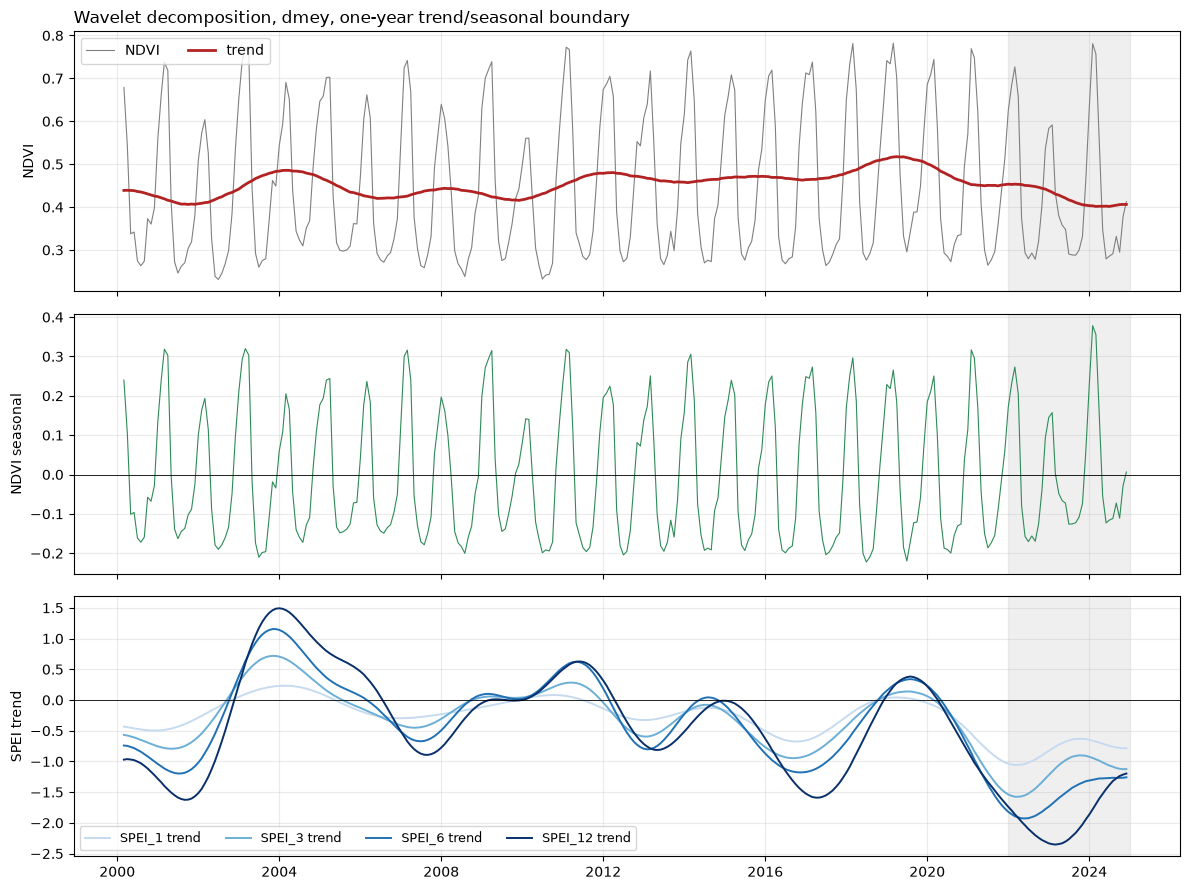

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
d = decomp.index

axes[0].plot(d, decomp["NDVI"], color="grey", lw=0.8, label="NDVI")
axes[0].plot(d, decomp["NDVI_T"], color="firebrick", lw=2, label="trend")
axes[0].set_ylabel("NDVI")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(d, decomp["NDVI_S"], color="seagreen", lw=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("NDVI seasonal")

for col, shade in zip(SPEI_COLS, ["#c6dbef", "#6baed6", "#2171b5", "#08306b"]):
    axes[2].plot(d, decomp[f"{col}_T"], lw=1.4, color=shade, label=f"{col} trend")
axes[2].axhline(0, color="black", lw=0.6)
axes[2].set_ylabel("SPEI trend")
axes[2].legend(loc="lower left", ncol=4, fontsize=9)

for ax in axes:
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2024-12-31"),
               color="grey", alpha=0.12, zorder=0)
    ax.grid(alpha=0.25)

axes[0].set_title("Wavelet decomposition, dmey, one-year trend/seasonal boundary",
                  loc="left")
fig.tight_layout()
fig.savefig("../figures/02_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

## The look-ahead problem

`pywt.mra` is a two-sided filter. The trend at month *t* is computed from neighbours
on **both** sides of *t*, so it already contains information from months that had not
yet happened. Every trend value above is partly a hindsight estimate.

For describing a historical record that is correct and standard. For forecasting it
is a problem, and one this literature does not generally acknowledge: a model that
predicts the trend component is scored on a target constructed using the future it
is supposed to predict.

The obvious way to measure the effect is to recompute the decomposition causally —
at every point in time, using only the observations available up to that point,
exactly as a forecaster would have had to — and compare how easily each version can
be predicted trivially:

- **lag-1 autocorrelation** — how much of the next value is already in the last one
- **persistence R²** — the skill of simply predicting "same as last month"

That is what the next cell does. It is also, as the section after it shows, the
wrong answer.

In [6]:
def causal_trend(series, level, burn_in):
    """Trend at each t recomputed from observations up to t only."""
    out = np.full(len(series), np.nan)
    for t in range(burn_in, len(series) + 1):
        trend, _, _ = decompose(series.iloc[:t], level)
        out[t - 1] = trend.iloc[-1]
    return pd.Series(out, index=series.index)


BURN_IN_YEARS = 8
PER_YEAR = {"NDVI": 365.25 / 16, "LST": 365.25 / 8, "SPEI": 12}

for name, series in [("NDVI", ndvi16), ("LST", lst8)]:
    burn = int(BURN_IN_YEARS * PER_YEAR[name])
    decomp[f"{name}_Tc"] = (causal_trend(series, LEVELS[name], burn)
                            .resample("MS").mean())

for col in SPEI_COLS:
    decomp[f"{col}_Tc"] = causal_trend(master[col], LEVELS["SPEI"],
                                       int(BURN_IN_YEARS * PER_YEAR["SPEI"]))

print(f"{'series':9s} {'lag-1 (2-sided)':>16s} {'lag-1 (causal)':>15s} "
      f"{'persist R2 2-sided':>19s} {'persist R2 causal':>18s} {'corr':>7s}")
for col in ALL_SERIES:
    a, b = decomp[f"{col}_T"], decomp[f"{col}_Tc"]
    m = b.notna()
    a, b = a[m], b[m]
    print(f"{col:9s} {a.autocorr(1):16.4f} {b.autocorr(1):15.4f} "
          f"{r2_score(a[1:], a[:-1]):19.4f} {r2_score(b[1:], b[:-1]):18.4f} "
          f"{a.corr(b):7.3f}")

series     lag-1 (2-sided)  lag-1 (causal)  persist R2 2-sided  persist R2 causal    corr
NDVI                0.9973          0.9081              0.9946             0.8166   0.498
LST                 0.9883          0.8775              0.9767             0.7541   0.167
SPEI_1              0.9974          0.9395              0.9947             0.8795   0.784
SPEI_3              0.9971          0.9743              0.9942             0.9486   0.806
SPEI_6              0.9970          0.9859              0.9940             0.9718   0.829
SPEI_12             0.9971          0.9903              0.9943             0.9806   0.867


### Why that comparison is not valid

Taken at face value the table says the look-ahead is enormous: NDVI persistence R²
falls from 0.994 to 0.817, and the two trends correlate at only 0.50.

Plotting the causal trend shows why that reading is wrong. It **oscillates
annually**, and a trend component must not: the decomposition was designed to put
everything faster than a year into the seasonal part. The oscillation is a boundary
artefact. At the right-hand edge of a growing window the filter has no future data,
so it extrapolates, and what it extrapolates reflects the seasonal phase the window
happens to end on.

The cell below shows this is not a padding choice that can be tuned away. Mirroring
the recent past, holding the last value, and no padding at all each leak the annual
cycle at four to eight times the amplitude of the trend itself.

So the drop from 0.994 to 0.817 conflates two different things — genuine loss of
hindsight, and seasonal contamination of the causal estimate — and reporting it as
the look-ahead effect would overstate the problem substantially. This is worth
stating in the paper in its own right: the obvious way to audit a two-sided filter
for look-ahead does not work, and anyone attempting it should know why.

A valid causal reference has to be an estimator that *cannot* leak the cycle. A
trailing 12-month mean is the simplest: strictly backward-looking, and because it
averages over exactly one annual period its seasonal response is zero by
construction. It is also comparably smooth, which makes the persistence comparison a
comparison of hindsight rather than of smoothness.

In [7]:
def causal_last(x, level, right_pad):
    """Trend value at the final point of x, under a given right-edge rule."""
    n = len(x)
    p = int(0.5 * n)
    right = {"mirror": x[-p:][::-1],
             "constant": np.full(p, x[-1]),
             "none": np.empty(0)}[right_pad]
    xp = np.concatenate([x[:p][::-1], x, right])
    return pywt.mra(xp, WAVELET, level=level,
                    transform="dwt", mode="symmetric")[0][p + n - 1]


x = ndvi16.to_numpy(float)
burn = int(BURN_IN_YEARS * PER_YEAR["NDVI"])

variants = {"wavelet, two-sided": decomp["NDVI_T"]}
for rule in ("mirror", "constant", "none"):
    out = np.full(len(x), np.nan)
    for t in range(burn, len(x) + 1):
        out[t - 1] = causal_last(x[:t], LEVELS["NDVI"], rule)
    variants[f"causal wavelet, {rule} pad"] = (
        pd.Series(out, index=ndvi16.index).resample("MS").mean())

for w in (12, 24):
    variants[f"trailing {w}-month mean"] = decomp["NDVI"].rolling(w).mean()

print(f"{'estimator':30s} {'sd':>7s} {'annual leak':>12s} {'lag-1':>7s} "
      f"{'persist R2':>11s} {'corr w/ 2-sided':>16s}")
for name, c in variants.items():
    k = c.notna()
    amp = (c[k].groupby(c[k].index.month).mean()
                .pipe(lambda v: v.max() - v.min()))
    print(f"{name:30s} {c.std():7.4f} {amp:12.4f} {c[k].autocorr(1):7.4f} "
          f"{r2_score(c[k][1:], c[k][:-1]):11.4f} "
          f"{decomp['NDVI_T'][k].corr(c[k]):16.3f}")

estimator                           sd  annual leak   lag-1  persist R2  corr w/ 2-sided
wavelet, two-sided              0.0281       0.0018  0.9968      0.9936            1.000
causal wavelet, mirror pad      0.0517       0.1099  0.9081      0.8166            0.498
causal wavelet, constant pad    0.0914       0.2274  0.8350      0.6692            0.271
causal wavelet, none pad        0.0479       0.1011  0.9002      0.8009            0.463
trailing 12-month mean          0.0327       0.0008  0.9742      0.9483            0.707
trailing 24-month mean          0.0243       0.0023  0.9916      0.9832            0.677


### What this means for the paper

Three statements, in decreasing order of confidence.

**The trend component uses the future.** This is a fact about the filter, not an
empirical claim, and it applies to every study in this literature that forecasts a
wavelet trend component.

**It inflates apparent forecast skill, moderately.** Measured against a strictly
causal trend of comparable smoothness, persistence R² falls from 0.994 to 0.948 and
the two trends correlate at 0.71. Absolute accuracy figures on trend branches are
therefore not pure forecast skill — but the inflation is a few points, not tens of
points. The Phase 1 reproduction reported a much larger gap, 0.997 against 0.912;
that figure came from the causal *wavelet*, and the section above shows why it
overstates the effect.

**It does not affect this paper's claim.** All three model classes receive identical
inputs, so a comparison of their attributions is unaffected by how the target was
constructed. The limitation is declared because it bears on the accuracy figures the
paper also reports, not because it threatens the result.

Both causal variants are saved. `_Tc` is the causal wavelet, kept as the evidence
for the boundary-artefact finding. `_Tm` is the trailing 12-month mean, which
notebook 04 can use for a sensitivity check so the limitation is backed by a number
measured on this dataset rather than asserted.

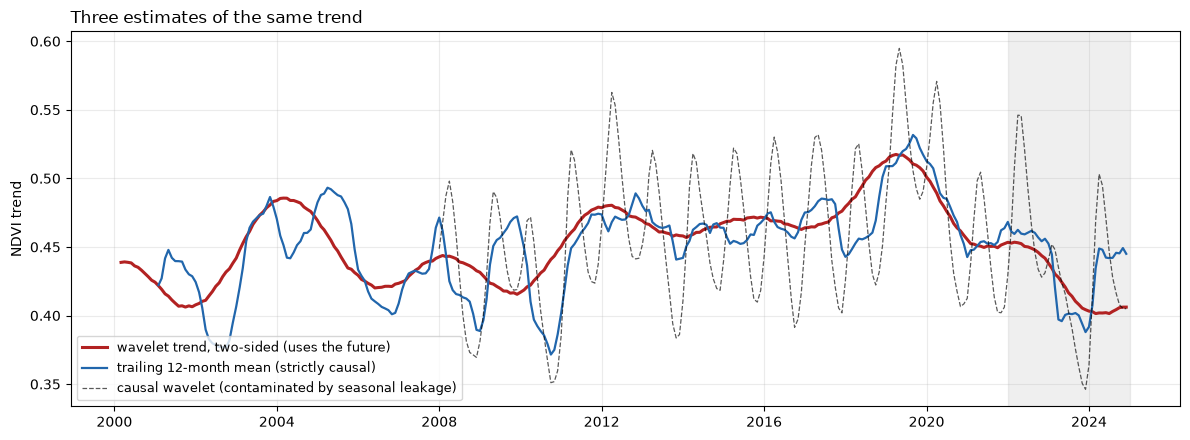

In [8]:
for col in ALL_SERIES:
    decomp[f"{col}_Tm"] = decomp[col].rolling(12).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(decomp.index, decomp["NDVI_T"], color="firebrick", lw=2.2,
        label="wavelet trend, two-sided (uses the future)")
ax.plot(decomp.index, decomp["NDVI_Tm"], color="#2166ac", lw=1.6,
        label="trailing 12-month mean (strictly causal)")
ax.plot(decomp.index, decomp["NDVI_Tc"], color="black", lw=0.9, ls="--",
        alpha=0.65, label="causal wavelet (contaminated by seasonal leakage)")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2024-12-31"),
           color="grey", alpha=0.12, zorder=0)
ax.set_ylabel("NDVI trend")
ax.grid(alpha=0.25)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("Three estimates of the same trend", loc="left")
fig.tight_layout()
fig.savefig("../figures/02_causal_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

One table, monthly, indexed by date. For each of the six series it carries the
series itself and four derived columns:

| suffix | meaning |
|---|---|
| `_T` | trend, two-sided wavelet — the primary component |
| `_S` | seasonal, defined as the residual, so `_T + _S` is exact |
| `_Tc` | causal wavelet trend, kept as evidence of the boundary artefact |
| `_Tm` | trailing 12-month mean, the strictly causal reference |

Notebook 03 builds features from `_T` and `_S`. The other two exist for the
sensitivity check described above and are not used as predictors.

In [9]:
decomp.to_csv("../data/processed/orchard_decomposed.csv")

print(decomp.shape)
print(f"\nnulls by suffix:")
for suffix in ("", "_T", "_S", "_Tc", "_Tm"):
    cols = [f"{c}{suffix}" for c in ALL_SERIES]
    print(f"  {suffix or '(series)':10s} {decomp[cols].isna().sum().sum():4d}  "
          f"first valid {decomp[cols].dropna().index[0].date()}")

(298, 32)

nulls by suffix:
  (series)      0  first valid 2000-03-01
  _T            0  first valid 2000-03-01
  _S            0  first valid 2000-03-01
  _Tc         569  first valid 2008-02-01
  _Tm          66  first valid 2001-02-01


## What notebook 02 established

**The levels are derived, not inherited.** Targeting a one-year trend/seasonal
boundary fixes them at 5, 6 and 4 for 16-day NDVI, 8-day LST and monthly SPEI, with
the neighbouring levels off by a factor of two in each case. They agree with
Bounouh et al. (2024) Table 3, whose reported semi-periods are reproduced exactly
once their 7-day MOD11A2 interval and 30-day month are accounted for.

**The decomposition reconstructs exactly.** Trend plus seasonal recovers every
series to machine precision, which the residual definition guarantees and the
denoising alternative does not.

**Quality screening was worth doing.** With the eight cloud-flagged NDVI composites
interpolated rather than kept, the finest detail band falls from 13.1% to 9.9% of
the NDVI standard deviation. A quarter of what looked like high-frequency signal was
cloud contamination, concentrated in a handful of dates.

**The trend tracks drought rather than drifting.** The NDVI trend runs 0.40 to 0.52
and back to 0.40, turning at the same times as the SPEI trends, with the 2000–2002
and 2022–2024 droughts both visible. Against the near-constant woody canopy
established in notebook 01, this is the expected behaviour and a point in favour of
the decomposition.

**The four SPEI scales are not interchangeable.** Trend share of variance rises
monotonically from 8.8% at one month to 70.4% at twelve, and the finest detail band
falls from 65.3% to 14.9%. `SPEI_1` additionally has a seasonally biased
climatology, reaching about −1.0 in July where the other months sit near −0.2.
Notebook 03 has to treat the scales as distinct predictors rather than as one
variable measured four ways.

**The look-ahead is real but moderate, and the obvious way to measure it fails.**
Recomputing the decomposition causally appears to show a collapse in predictability,
from 0.994 to 0.817 persistence R². Inspection shows the causal estimate oscillates
annually — a boundary artefact present under every right-edge padding rule tested,
at four to eight times the amplitude of the trend itself. Against a trailing
12-month mean, which cannot leak the annual cycle, persistence R² falls only from
0.994 to 0.948 and the two trends correlate at 0.71.

The limitation stands and is declared: absolute accuracy on trend branches is not
pure forecast skill. Its magnitude is a few points of R², not the collapse the naive
audit suggests, and the Phase 1 reproduction's figure of 0.997 against 0.912 is
superseded by the measurement above.

None of this affects the paper's central claim, since all three model classes
receive identical inputs and the comparison between their attributions is unchanged
by how the target was built.